### Oppgave 1.1
Plot av det loagitmiske potensialet F(u) for $u \in [-1,1]$ for $\theta = [0.7,1.6]$ med $ \theta < \theta_c$, $ \theta = \theta_c$ og $ \theta > \theta_c$ for en kritisk temperatur $\theta_c = 1.5$

In [1223]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fft, fftfreq, fftshift, ifft, ifftshift
import sympy as sy
from sympy import sin, cos, exp
import pandas as pd
from tqdm import tqdm

plt.rcParams.update({
     "font.family": "serif",             
    "mathtext.fontset": "cm",
    "font.size": 12,                
    "axes.titlesize": 16,           
    "axes.labelsize": 16,           
    "xtick.labelsize": 10,          
    "ytick.labelsize": 10,          
    "legend.fontsize": 10,          
    "lines.linewidth": 2,           
    "axes.grid": True,              
    "grid.linestyle": "--",         
    "grid.alpha": 0.6, 
})

In [1224]:
theta_vals = np.linspace(0.7,1.6,10)
theta_c = 1.5
u_start = -1
u_stop = 1
def plot_logF(u_start,u_stop,theta_vals, theta_c):
    for j in range(len(theta_vals)):
        n = 1000
        u_vals = np.linspace(u_start,u_stop,n)

        y_vals = np.zeros(n)
        for i in range(n):
            y_vals[i] = (theta_c/2)*(1-u_vals[i]**2) + (theta_vals[j]/2)*( (1-u_vals[i])*(np.log((1-u_vals[i])/2))+ (1+u_vals[i])*np.log((1+u_vals[i])/2))
        plt.plot(u_vals,y_vals, label = fr"$\theta$ = {np.round(theta_vals[j],2)}")
        plt.xlabel("u")
        plt.ylabel("y")
    plt.title(r"F(u) for forskjellige $\theta$ verdier")
    plt.legend()
    plt.show()

C:\Users\eirik\AppData\Local\Temp\ipykernel_7476\3833406382.py:12: RuntimeWarning: divide by zero encountered in log
  y_vals[i] = (theta_c/2)*(1-u_vals[i]**2) + (theta_vals[j]/2)*( (1-u_vals[i])*(np.log((1-u_vals[i])/2))+ (1+u_vals[i])*np.log((1+u_vals[i])/2))
C:\Users\eirik\AppData\Local\Temp\ipykernel_7476\3833406382.py:12: RuntimeWarning: invalid value encountered in double_scalars
  y_vals[i] = (theta_c/2)*(1-u_vals[i]**2) + (theta_vals[j]/2)*( (1-u_vals[i])*(np.log((1-u_vals[i])/2))+ (1+u_vals[i])*np.log((1+u_vals[i])/2))


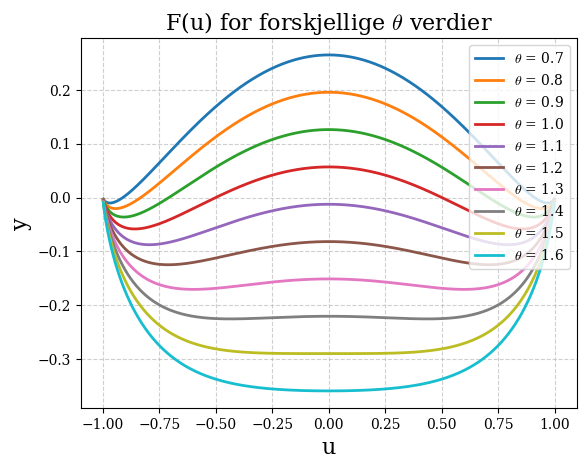

In [1225]:
plot_logF(u_start, u_stop, theta_vals, theta_c)

### oppgave 1b)
Vis at Cahn-hillard likningen er uendret av transformasjonen u -> -u
Vi har likningen:  
$ \partial_t u \;-\; \nabla \cdot\bigl(M\,\nabla\bigl(f(u)\bigr) \;-\; \kappa\,\Delta u\bigr)
\;=\; 0
\quad \text{på } \Omega\times(0,T)$

Operatoren $\partial_t$ er lineær. Noe som gir 
$-\partial_t u$ ved transformasjonen

f(u) er også en ikke lineær funksjon. ved transformasjonen u -> -u får vi:  
$f(-u) = (u^2 - 1) \cdot (-u) = -f(u)$

Operatoren $\nabla $ er også lineær

Det hele resulterer i at transformasjonen u-> -u også er en løsning av Cahn-Hillard likningen



### oppgave 1c)
Vis at løsningen av Cahn-hillard likningen som er periodisk på et kvadratisk område er massekonservativt i sammenhengen at $\frac{d}{dt} \int_{\Omega} u(x,t)\,dx = 0$

### oppgave 2)
implementer en spectral løser for den biharmoniske likningen i 2d)  

$\Delta^2 u + c\,u = f
\quad \text{in } \Omega$

In [1226]:
"""
Solve the biharmonic equation in 2D using the spectral method.
Parameters:
    X (ndarray): 2D array of x-coordinates.
    Y (ndarray): 2D array of y-coordinates.
    F (ndarray): 2D array representing the right-hand side of the biharmonic equation.
    c (float): Constant coefficient in the biharmonic equation.
    mean (float, optional): Desired mean value of the solution in case c = 0. Default is 0.0.

Returns:
    U (ndarray): 2D array representing the solution to the biharmonic equation.
"""

def biharmonic_solver(X, Y, F,Lx,Ly,Nx,Ny,c,mean=0.0):
    
    #fourier transform av høyre siden av likningen
    F_hat = fft2(F)

    # Bølgetall grid
    kx = fftfreq(Nx, d=(Lx/Nx))*(2*np.pi)
    ky = fftfreq(Ny, d=(Ly/Ny))*(2*np.pi)
    KX, KY = np.meshgrid(kx, ky, indexing= "ij")
    
    # Multiplikator for fourier rommet
    K2 = (KX**2 + KY**2)**2 + c
    # For å unngå å dele på 0
    K2[0,0] = 1
    
    #Vi løser nå for U i fourier rommet
    U_hat = F_hat/(K2)
    #setter [0,0] til å være lik gjennomsnittsverdien
    U_hat[0,0] = mean
    #Transformerer tilbake.
    U = np.real(ifft2(U_hat))
    return U

In [1227]:
def manufacture_exact_sol(u_str,c):
    x,y = sy.symbols('x y')
    #gjør om string til funksjon eller sympy objekt
    u_sy = sy.sympify(u_str)

    laplace = lambda expr: sy.diff(expr, x,2) + sy.diff(expr,y,2)
    
    laplace1 = laplace(u_sy)
    biharmonic  = laplace(laplace1)

    f_sy = sy.simplify(biharmonic + c*u_sy)
    #print(f"u: {u_sy}")
    #print(f"f: {f_sy}")
    u = sy.lambdify((x, y), u_sy, modules='numpy')
    f = sy.lambdify((x, y), f_sy, modules='numpy')
    return f,u

In [1228]:
def EOC_and_error(Nx_list,Ny_list,Lx,ly,F,c):
    error_list = np.zeros(len(Nx_list))
    EOC_list = np.zeros(len(Nx_list))
    #lager tomme lister
    for i in range(len(Nx_list)):
        Nx = Nx_list[i]
        Ny = Ny_list[i]
        #lager det kvadratiske systemet
        x = np.linspace(0,Lx,Nx, endpoint= False)
        y = np.linspace(0,Ly,Ny, endpoint= False)
        X,Y = np.meshgrid(x,y, indexing= "ij")

        f,u_exact = manufacture_exact_sol(F,c)
        U = biharmonic_solver(X,Y,f(X,Y),Lx,Ly,Nx,Ny,c,mean = 0.0)
        U += np.mean(u_exact(X,Y))
        err = np.linalg.norm(U - u_exact(X,Y), np.inf)
        error_list[i] = err
    EOC_list = np.log(error_list[:-1]/error_list[1:])/np.log((Lx/Nx_list[:-1])/(Lx/Nx_list[1:]))
    EOC_list = np.insert(EOC_list,0,np.inf)
    return Nx_list, Ny_list, error_list, EOC_list

In [1229]:
Lx = 2*np.pi
ly = 4*np.pi
Nx_list = np.array([4,8,15,16,20,32])
Ny_list = 2*Nx_list
F1 = 'sin(8*(x-1))*cos(4*y)'
values1 = EOC_and_error(Nx_list,Ny_list, Lx,Ly,F1,1)

df = pd.DataFrame({
    "Nx": values1[0],
    "Ny": values1[1],
    "Error": values1[2],
    "EOC": values1[3]
})
df

,Nx,Ny,Error,EOC
0,4,8,1.892177e+02,inf
1,8,16,1.892177e+02,-6.887367e-14
2,15,30,9.827684e+00,4.705145e+00
3,16,32,7.233819e-13,4.685580e+02
4,20,40,5.472289e-13,1.250630e+00
5,32,64,8.862393e-13,-1.025779e+00


In [1230]:
F2 = 'exp(sin(x)**2 + cos(2*y))'
k = np.arange(10)
Nx_list_1 = np.array(np.zeros(len(k), dtype=int))
for i in range(len(k)):
    Nx_list_1[i] = (4+4*k[i])
Ny_list_1 = 2*Nx_list_1

values2 = EOC_and_error(Nx_list_1,Ny_list_1, Lx,Ly,F2,0)

In [1231]:
df_1 = pd.DataFrame({
    "Nx": values2[0],
    "Ny": values2[1],
    "Error": values2[2],
    "EOC": values2[3]
})
df_1

,Nx,Ny,Error,EOC
0,4,8,5.652322e+01,inf
1,8,16,1.449297e+01,1.963491
2,12,24,7.647599e-01,7.255512
3,16,32,1.495692e-02,13.676167
4,20,40,3.183037e-04,17.253123
5,24,48,8.315621e-06,19.991438
6,28,56,2.186278e-07,23.603660
7,32,64,5.411110e-09,27.700728
8,36,72,1.243503e-10,32.034382
9,40,80,3.339551e-12,34.332276


In [1232]:
def plot_solutions_all(Nx_list, Ny_list, Lx, Ly, F, c):
    """
    Plotter (Exact, Numerical, Error) i hver sin kolonne for hver (Nx, Ny).
    Antall rader = len(Nx_list), antall kolonner = 3.
    """

    # Antall rader og kolonner i subplot-ruten
    nrows = len(Nx_list)
    ncols = 3

    # Opprett en figur med riktig antall akser (3D-subplots).
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(12, 4*nrows),
                             subplot_kw={'projection': '3d'})

    # Hvis nrows == 1, blir axes en 1D-array på [3,], vi gjør den 2D for enkel looping.
    if nrows == 1:
        axes = np.array([axes])

    for i, (Nx, Ny) in enumerate(zip(Nx_list, Ny_list)):
        # Bygg rutenett
        x = np.linspace(0, Lx, Nx, endpoint=False)
        y = np.linspace(0, Ly, Ny, endpoint=False)
        X, Y = np.meshgrid(x, y, indexing="ij")

        # Hent eksakt løsning og høyreside
        f, u_exact = manufacture_exact_sol(F, c)   # <-- du må ha denne funksjonen definert
        # Løs med din biharmoniske solver
        U = biharmonic_solver(X, Y, f(X, Y), Lx, Ly, Nx, Ny, c, mean=0.0)
        # Justér mean om nødvendig (avhenger av PDE-setup)
        U += np.mean(u_exact(X, Y))

        error = np.abs(u_exact(X, Y) - U)

        # ============== Exact =================
        ax1 = axes[i, 0]
        surf1 = ax1.plot_surface(X, Y, u_exact(X, Y),
                                 cmap='viridis', edgecolor='none')
        ax1.set_title(f'Exact (Nx={Nx}, Ny={Ny})')
        fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)

        # ============== Numerical =============
        ax2 = axes[i, 1]
        surf2 = ax2.plot_surface(X, Y, U,
                                 cmap='viridis', edgecolor='none')
        ax2.set_title(f'Numerical (Nx={Nx}, Ny={Ny})')
        fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)

        # ============== Error =================
        ax3 = axes[i, 2]
        surf3 = ax3.plot_surface(X, Y, error,
                                 cmap='hot', edgecolor='none')
        ax3.set_title(f'Error (max={np.max(error):.2e})')
        fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10, pad=0.1)

    plt.tight_layout()
    plt.show()

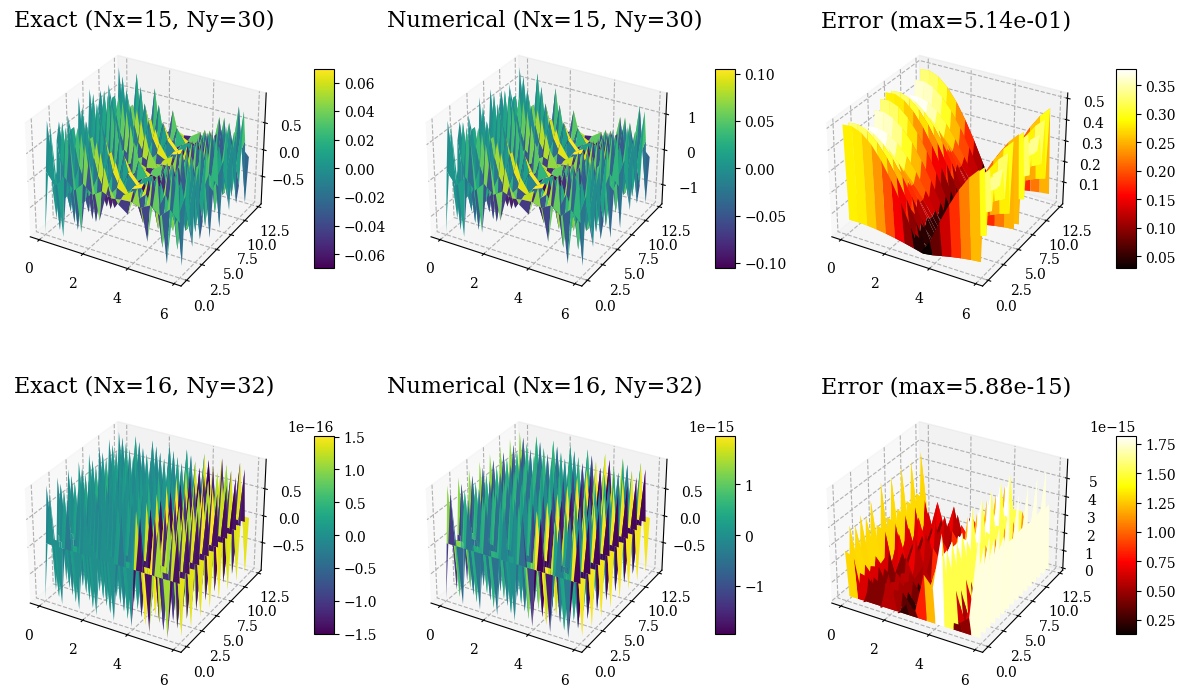

In [1233]:
Nx_list = np.array([15,16])
Ny_list = Nx_list*2
plot_solutions_all(Nx_list,Ny_list,Lx,ly,F1,c=1)

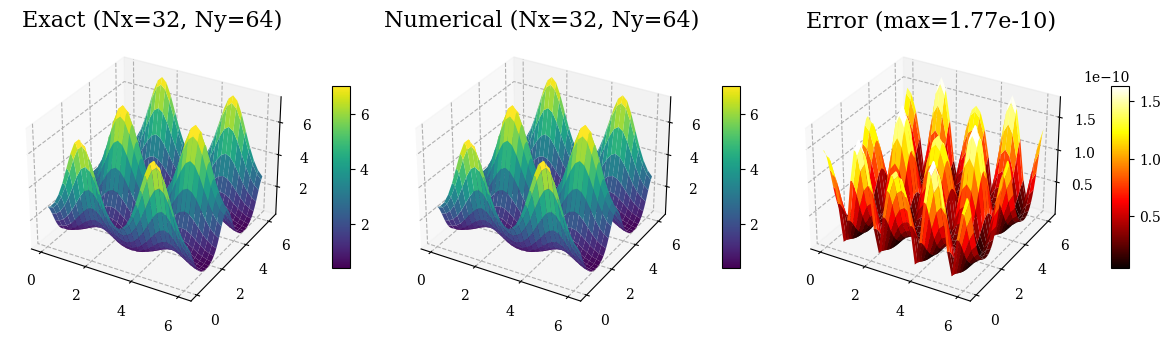

In [1234]:
Nx_list = np.array([32])
Ny_list = 2*Nx_list
plot_solutions_all(Nx_list, Ny_list, Lx,Ly,F2,c = 0)

### Oppgave 3)

En løsning for den biharmoniske tidsavhengige likningen  
$\partial_t u + \kappa \,\Delta^2 u = g$

#### a)
Skriv om $\theta$ metoden til en andre ordens runge kutta metode  
For hvilke verdier blir $\theta$ metoden redusert til andre godt kjente tidssteg metoder?

Oppgaven ber om at vi skal lage en butcher tabell for en 2 orden runge kutta metode og se på hvilke theta verdier som gjør at den kan tolkes som andre ODE løsere.

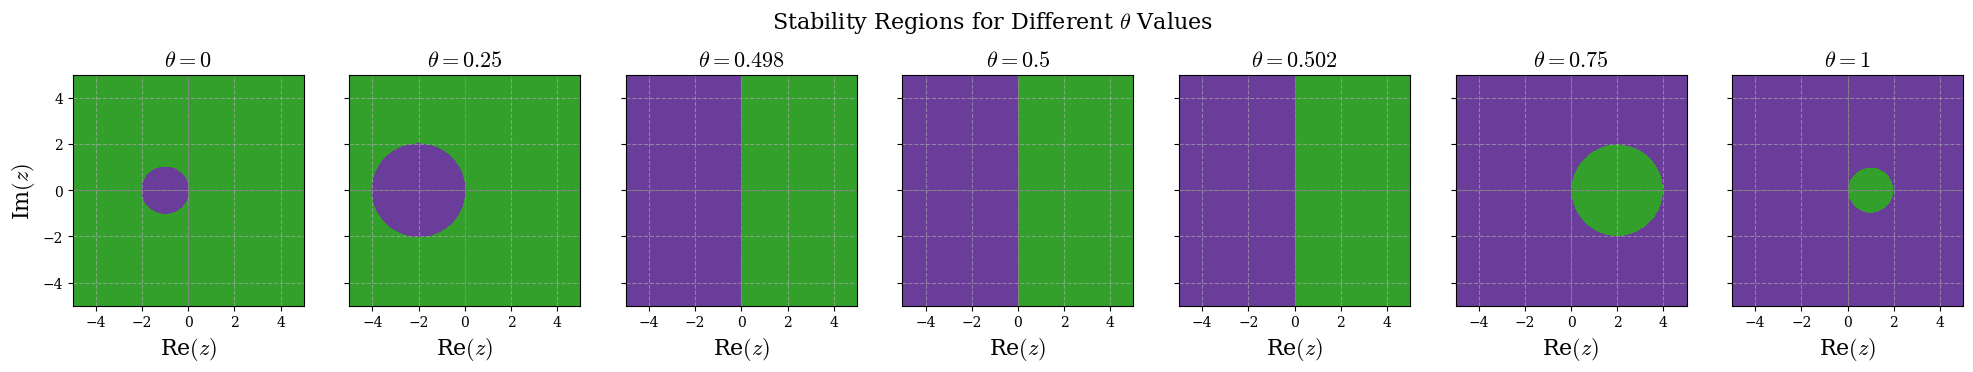

In [1235]:

a = np.linspace(-5, 5, 1000)
b = np.linspace(-5, 5, 1000)
A, B = np.meshgrid(a, b)
Z = A + B * 1j

# Stabilitetsfunksjonen
def Rz(Z, theta):
    R = 1 + Z / (1 - Z * theta)
    return np.abs(R)

fig, axes = plt.subplots(1, 7, figsize=(20, 5), sharex=True, sharey=True)

# Theta-verdier
theta_vals = [0, 0.25, 0.498, 0.5, 0.502,0.75,1]

# Plot hver region på sin egen aksis
for ax, theta in zip(axes, theta_vals):
    ax.contourf(A, B, Rz(Z, theta) <= 1, cmap='Paired', levels=1)
    ax.set_title(rf"$\theta = {theta}$")
    ax.set_xlabel("Re$(z)$")
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect("equal")

axes[0].set_ylabel("Im$(z)$")
fig.suptitle("Stability Regions for Different $\\theta$ Values", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=1.2)
plt.show()


In [1236]:
def transient_biharmonic_solver(*,kappa, X, Y, U0, t0, T, Nt,theta = 0.5,g=None):
    x, y = X[0,:], Y[:,0]
    Nx, Ny = len(x), len(y)

    dx, dy = x[1] - x[0], y[1] - y[0]

    kx = fftfreq(Nx, d=dx/(2*np.pi))
    ky = fftfreq(Ny, d=dy/(2*np.pi))
    KY,KY = np.meshgrid(kx,ky, indexing= "ij")

    K4 = (KY**2 + KY**2)**2

    t = t0
    dt = (T-t0)/Nt
    U_hat = fft2(U0)
    yield (U_hat, t)

    with tqdm(total=T) as pbar:
        while t < T-dt/2:
            if g is not None:
                G_hat = fft2(g(X,Y,t))
                G_hat_next = fft2(g(X,Y,t + dt))
            else:
                G_hat = 0
                G_hat_next = 0

            U_hat = (U_hat + dt*(theta*G_hat_next + (1-theta)*(G_hat - kappa*K4*U_hat)))/(1 + dt*theta*kappa*K4)
            t = t + dt
            pbar.update(dt)
            yield U_hat, t

In [1237]:
'''
def manufacture_exact_transient(u_str, kappa_val, lamb_val):
    # Definer symboler inkludert parameterne
    x, y, t, kappa_sym, lamb_sym = sy.symbols('x y t kappa lamb')
    
    # Gjør om strengen til et sympy-uttrykk
    u_sy = sy.sympify(u_str)
    
    # Erstatt de symbolske parameterne med de numeriske verdiene
    u_sy = u_sy.subs({kappa_sym: kappa_val, lamb_sym: lamb_val})
    
    # Definer Laplace-operatoren med hensyn på x og y
    laplace = lambda expr: sy.diff(expr, x, 2) + sy.diff(expr, y, 2)
    laplace1 = laplace(u_sy)
    biharmonic = laplace(laplace1)
    
    # Beregn høyresiden: kappa*biharmonic + tidsderivert av u.
    # Her tas den første derivert med hensyn på t
    g_sy = sy.simplify(kappa_val * biharmonic + sy.diff(u_sy, t))
    
    print(f"u: {u_sy}")
    print(f"g: {g_sy}")
    print(f"u(x,y,0) = {u_sy.subs(t,0)}")
    
    # Lag numeriske funksjoner for u og g med lambdify
    u = sy.lambdify((x, y, t), u_sy, modules='numpy')
    g = sy.lambdify((x, y, t), g_sy, modules='numpy')
    
    return g, u'
'''

'\ndef manufacture_exact_transient(u_str, kappa_val, lamb_val):\n    # Definer symboler inkludert parameterne\n    x, y, t, kappa_sym, lamb_sym = sy.symbols(\'x y t kappa lamb\')\n    \n    # Gjør om strengen til et sympy-uttrykk\n    u_sy = sy.sympify(u_str)\n    \n    # Erstatt de symbolske parameterne med de numeriske verdiene\n    u_sy = u_sy.subs({kappa_sym: kappa_val, lamb_sym: lamb_val})\n    \n    # Definer Laplace-operatoren med hensyn på x og y\n    laplace = lambda expr: sy.diff(expr, x, 2) + sy.diff(expr, y, 2)\n    laplace1 = laplace(u_sy)\n    biharmonic = laplace(laplace1)\n    \n    # Beregn høyresiden: kappa*biharmonic + tidsderivert av u.\n    # Her tas den første derivert med hensyn på t\n    g_sy = sy.simplify(kappa_val * biharmonic + sy.diff(u_sy, t))\n    \n    print(f"u: {u_sy}")\n    print(f"g: {g_sy}")\n    print(f"u(x,y,0) = {u_sy.subs(t,0)}")\n    \n    # Lag numeriske funksjoner for u og g med lambdify\n    u = sy.lambdify((x, y, t), u_sy, modules=\'numpy\')

In [1238]:
#manufacture solutions
def manufacture_exact_transient(u_string,kappa):

    x, y, t = sy.symbols('x y t')
    u_symbolic = eval(u_string)

    laplace = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    
    #beregner dobbel laplace på funksjonen (laplace^2)
    firstLaplace = laplace(u_symbolic)
    biharmonic = laplace(firstLaplace)
    g_symbolic = kappa*biharmonic + sy.diff(u_symbolic,t,1) 

    u = sy.lambdify((x, y, t), u_symbolic, modules='numpy')
    g = sy.lambdify((x, y, t), g_symbolic, modules='numpy')
    print(f'u = {u_symbolic}')
    print(f'u0 = {u_symbolic.subs(t, 0)}')
    print(f'g = {g_symbolic}')

    return u,g

In [1245]:
def compute_eoc_transient(*,kappa, u_ex, U0, g,X, Y, t0, T, Nt_list,theta):
    errs_Nt = []
    for Nt in Nt_list:
        U_list = transient_biharmonic_solver(kappa = kappa, X = X, Y = Y,
                                            U0 = U0, t0 = t0, T = T,
                                            Nt = Nt,theta = theta,g = g)
        errs_t = []
        for U_hat, t in U_list:
            U = ifft2(U_hat).real
            U_ex = u_ex(X,Y,t)
            U_err = U - U_ex
            # Record maximum error at current time step
            errs_t.append(np.linalg.norm(U_err, np.inf))
        # Record maximum error over all time steps 
        errs_Nt.append(np.array(np.linalg.norm(errs_t, np.inf)))
        
    Nt_list = np.array(Nt_list)
    errs_Nt = np.array(errs_Nt)
    eocs = np.log(errs_Nt[1:]/errs_Nt[:-1])/np.log(Nt_list[:-1]/Nt_list[1:])
    eocs = np.insert(eocs, 0, np.inf)
    return errs_Nt, eocs

In [1246]:
#løsningsforberedelser
Lx,Ly = np.pi,np.pi
Nx,Ny = 20,20
x = np.linspace(-Lx,Lx,Nx,endpoint=False)
y = np.linspace(-Ly,Ly,Ny,endpoint=False)
X,Y = np.meshgrid(x,y,sparse=True)

#parametere
kappa = 1
T,t0 = 1,0

#velger lambda lik 4, da blir g(x,y,t) lik 0
lamb = 4
Nt_list = [10,20,40,80,160,320,640]
g = None

#string representasjon av funksjonen
u_string_ex = 'sin(x)*cos(y)*exp(-lamb*kappa*t)'
u_ex,g_exact = manufacture_exact_transient(u_string_ex,kappa)

u0 = u_ex
U0 = u0(X,Y,0)


errs_Nt_1, eocs_1 = compute_eoc_transient(kappa = kappa,u_ex = u0,
                                        U0 = U0,g = g,X = X,Y = Y,
                                        t0 = t0,T = T,Nt_list = Nt_list,
                                        theta = 0)

errs_Nt_2, eocs_2 = compute_eoc_transient(kappa = kappa,u_ex = u_ex,
                                        U0 = U0,g = g,X = X,Y = Y,
                                        t0 = t0,T = T,Nt_list = Nt_list,
                                        theta = 0.5)

errs_Nt_3, eocs_3 = compute_eoc_transient(kappa = kappa,u_ex = u_ex,
                                        U0 = U0,g = g,X = X,Y = Y,
                                        t0 = t0,T = T,Nt_list = Nt_list,
                                        theta = 1)

u = exp(-4*t)*sin(x)*cos(y)
u0 = sin(x)*cos(y)
g = 0


100%|█████████▉| 0.9999999999999999/1 [00:00<00:00, 312.33it/s]
100%|██████████| 1.0000000000000002/1 [00:00<00:00, 189.05it/s]
100%|██████████| 1.0000000000000004/1 [00:00<00:00, 124.77it/s]
100%|█████████▉| 0.9999999999999984/1 [00:00<00:00, 113.35it/s]
  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\eirik\AppData\Local\Temp\ipykernel_7476\3431244517.py:27: RuntimeWarning: overflow encountered in multiply
  U_hat = (U_hat + dt*(theta*G_hat_next + (1-theta)*(G_hat - kappa*K4*U_hat)))/(1 + dt*theta*kappa*K4)
C:\Users\eirik\AppData\Local\Temp\ipykernel_7476\3431244517.py:27: RuntimeWarning: invalid value encountered in multiply
  U_hat = (U_hat + dt*(theta*G_hat_next + (1-theta)*(G_hat - kappa*K4*U_hat)))/(1 + dt*theta*kappa*K4)
100%|█████████▉| 0.9999999999999974/1 [00:00<00:00, 85.34it/s]
100%|██████████| 1.0000000000000058/1 [00:00<00:00, 50.48it/s]
100%|██████████| 1.00000000000001/1 [00:00<00:00, 29.97it/s]
100%|█████████▉| 0.9999999999999999/1 [00:00<?, ?it/s]
100%|██████████| 1.000

In [1247]:
df_t1 = pd.DataFrame({
    "Nt": Nt_list,
    "Error": errs_Nt_1,
    "EOC": eocs_1
})
df_t1

,Nt,Error,EOC
0,10,2.379482e+20,inf
1,20,2.361697e+50,-99.647019
2,40,2.185686e+104,-179.272380
3,80,1.603289e+200,-318.458046
4,160,NaN,NaN
5,320,NaN,NaN
6,640,NaN,NaN


In [1248]:
df_t2 = pd.DataFrame({
    "Nt": Nt_list,
    "Error": errs_Nt_2,
    "EOC": eocs_2
})
df_t2

,Nt,Error,EOC
0,10,0.061848,inf
1,20,0.015552,1.991623
2,40,0.003875,2.004710
3,80,0.000968,2.001173
4,160,0.000242,2.000293
5,320,0.000060,2.000073
6,640,0.000015,2.000018


In [1249]:
df_t3 = pd.DataFrame({
    "Nx": Nt_list,
    "Error": errs_Nt_3,
    "EOC": eocs_3
})
df_t3

,Nx,Error,EOC
0,10,0.798529,inf
1,20,0.429312,0.895320
2,40,0.223050,0.944656
3,80,0.113774,0.971194
4,160,0.057470,0.985292
5,320,0.028883,0.992567
6,640,0.014479,0.996263
